## Задача 1

Реализовать класс для работы с линейной регрессией

In [795]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge, ElasticNet

In [ ]:
class MyLinearRegression:
    """
    Parameters
    ----------
    regularization : {None, 'l1', 'l2', 'l1l2'}, default=None
        Какую регуляризацию добавить к модели. Если значение `None`, то без регуляризации.

    weight_calc : {'matrix', 'gd', 'sgd'}, default='matrix'
        Каким образом вычислять вектор весов: матрично ('matrix'), градиентным спуском ('gd') или стохастическим градиентным спуском ('sgd'). При этом, при 'l1' или 'l1l2' нельзя использовать параметр 'matrix'.

    Attributes
    ----------
    coefs_ : Вектор коэффициентов размера (p, 1), где p — количество признаков.
    intercept_ : Значение коэффициента, отвечающего за смещение
    """

    def __init__(self, regularization = None, weight_calc = 'matrix', lambda_1 = None, lambda_2 = None, batch_size = 20,
                 random_state = 42, alpha = 0.001, max_iter = 5000, early_stopping = 0.0001):
        if regularization not in [None, 'l1', 'l2', 'l1l2']:
            raise TypeError(f"Параметр regularization не может принимать значение '{regularization}'")
        if weight_calc not in ['matrix', 'gd', 'sgd']:
            raise TypeError(f"Параметр weight_calc не может принимать значение '{weight_calc}'")
        if regularization in ['l1', 'l1l2'] and lambda_1 is None:
            raise TypeError(f"Значение коэффициента регулризации l1 не задано")
        if regularization in ['l2', 'l1l2'] and lambda_2 is None:
            raise TypeError(f"Значение коэффициента регулризации l2 не задано")

        self.regularization = regularization
        self.weight_calc = weight_calc
        self.coefs_ = None
        self.intercept_ = None
        self.lambda_1 = lambda_1
        self.lambda_2 = lambda_2
        self.batch_size = batch_size
        self.random_state = random_state
        self.alpha = alpha
        self.max_iter = max_iter
        self.early_stopping = early_stopping
    
    def _initialization(self, X):

        np.random.seed(self.random_state)
        X_new = np.hstack((np.ones((X.shape[0], 1)), X))
        W = np.random.uniform(size = (X_new.shape[1], 1))
        return X_new, W

    def _get_gradient(self, X, Y, W):
      
        grad = 2 / X.shape[0] * X.T @ (X @ W - Y)
    
        if self.regularization == 'l1':
            grad[1:] += (self.lambda_1) * np.sign(W[1:])
        elif self.regularization == 'l2':
            grad[1:] += (2 * self.lambda_2) * W[1:]
        elif self.regularization == 'l1l2':
            grad[1:] += self.lambda_1 * np.sign(W[1:]) + 2 * self.lambda_2 * W[1:]
        
        return grad
    
    def GD_regression(self, X, Y):
        '''
        Gradient descent
        '''
        X_new, W = self._initialization(X)
        for _ in range(self.max_iter):

            grad = self._get_gradient(X_new, Y, W)
            W_new = W - self.alpha * grad

            if np.linalg.norm(W_new - W) < self.early_stopping:
                return W[0], W[1:]
            
            W = W_new

        return W[0], W[1:]
    
    def SGD_regression(self, X, Y):
        '''
        Stochastic gradient descent
        '''
        X_new, W = self._initialization(X)
        n_samples = X.shape[0]

        for _ in range(self.max_iter):
            indices = np.random.permutation(n_samples)

            X_shuffled = X_new[indices]
            y_shuffled = Y[indices]

            for j in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[j:j + self.batch_size]
                y_batch = y_shuffled[j:j + self.batch_size]

                grad = self._get_gradient(X_batch, y_batch, W)

                W_new = W - self.alpha * grad

                if np.linalg.norm(W_new - W) < self.early_stopping:
                    return W[0], W[1:]
                
                W = W_new

        return W[0], W[1:]

    def fit(self, X: np.array, y: np.array):
        '''
        Fit linear model.
        '''
        X_np = X
        y_np = y if len(y.shape) == 2 else y.reshape(-1, 1)

        if self.weight_calc == 'matrix':

            if self.regularization in ['l1', 'l1l2']:
                raise ValueError("L1 и L1L2 регуляризация не поддерживаются для матричного решения")

            X_new = np.hstack((np.ones((X_np.shape[0], 1)), X_np))

            theta_full = np.linalg.inv(X_new.T @ X_new) @ X_new.T @ y_np
            self.intercept_ = theta_full[0]
            self.coefs_ = theta_full[1:]

        elif self.weight_calc == 'gd':
            theta_full = self.GD_regression(X_np, y_np)
            self.intercept_ = theta_full[0][0]
            self.coefs_ = theta_full[1]
        
        else:
            theta_full = self.SGD_regression(X_np, y_np)
            self.intercept_ = theta_full[0][0]
            self.coefs_ = theta_full[1]
        
        return self

    def predict(self, X: np.array):
        '''
        Predict using the linear model.
        '''
        X_with_intercept = np.hstack((np.ones((X.shape[0], 1)), X))
        theta_full = np.vstack((self.intercept_, self.coefs_))

        return X_with_intercept @ theta_full

    def score(self, X: np.array, y: np.array) -> float:
        '''
        Return coefficient of determination on test data.
        '''
        y = y.reshape(-1, 1) if len(y.shape) == 1 else y
        y_pred = self.predict(X)
        u = np.sum((y - y_pred) ** 2)
        v = np.sum((y - np.mean(y)) ** 2)
        
        return 1 - (u / v)

Проверим реализованный класс на корректность, сравнив с библиотечным классом.

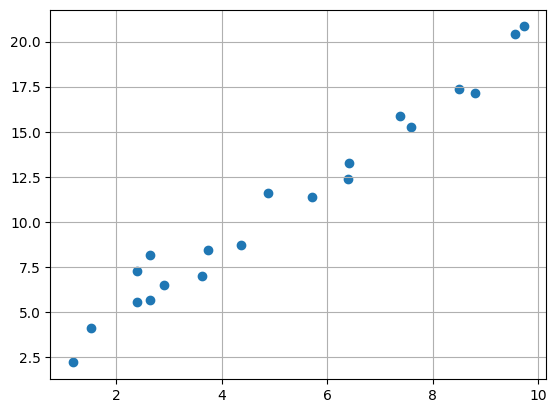

In [797]:
n_samples = 20
np.random.seed(42)

X = np.random.uniform(1, 10, (n_samples, 1))
y = (2 * X + 1 + np.random.normal(0, 1, (n_samples, 1)))

plt.grid(True)
plt.scatter(X, y)

**Матричное** решение

In [798]:
linreg = MyLinearRegression()
linreg.fit(X, y)
theta_0 = linreg.intercept_
theta = linreg.coefs_
linreg.intercept_, linreg.coefs_

(array([1.02099775]), array([[1.94260725]]))

In [799]:
linreg_ = LinearRegression().fit(X, y)
linreg_.intercept_, linreg_.coef_

(array([1.02099775]), array([[1.94260725]]))

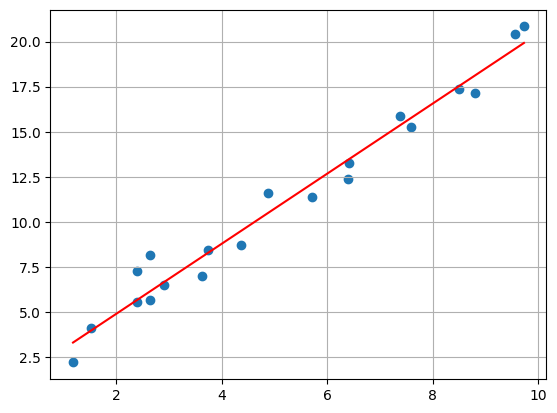

In [800]:
plt.scatter(X, y)
x = np.linspace(np.min(X), np.max(X), 100)
y2 = x * theta[0] + theta_0
plt.grid(True)
plt.plot(x, y2, color = 'red')
plt.show()

In [801]:
X_new = np.random.uniform(-10, 0, (100, 1))
y_new = (2 * X_new + 1 + np.random.normal(0, 1, (100, 1))).reshape(-1)
print(f'My Linear Regression: {linreg.score(X_new, y_new):.8f}')
y_pred = linreg_.predict(X_new)
print(f'Sklearn Regresion: {r2_score(y_new, y_pred):.8f}')

My Linear Regression: 0.97043909
Sklearn Regresion: 0.97043909


Решение **градиентным спуском**

In [802]:
linreg = MyLinearRegression(weight_calc = 'gd')
linreg.fit(X, y)
theta_0 = linreg.intercept_
theta = linreg.coefs_
linreg.intercept_, linreg.coefs_

(np.float64(0.7884781072302046), array([[1.97837489]]))

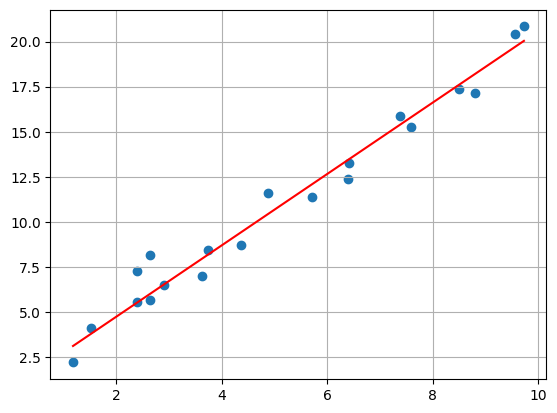

In [803]:
plt.scatter(X, y)
x = np.linspace(np.min(X), np.max(X), 100)
y2 = x * theta[0] + theta_0
plt.grid(True)
plt.plot(x, y2, color = 'red')
plt.show()

In [804]:
X_new = np.random.uniform(-10, 0, (100, 1))
y_new = (2 * X_new + 1 + np.random.normal(0, 1, (100, 1))).reshape(-1)
print(f'My Linear Regression: {linreg.score(X_new, y_new):.8f}')
y_pred = linreg_.predict(X_new)
print(f'Sklearn Regresion: {r2_score(y_new, y_pred):.8f}')

My Linear Regression: 0.97537191
Sklearn Regresion: 0.97291389


Решение **стохастическим градиентным спуском**

In [805]:
linreg = MyLinearRegression(weight_calc = 'sgd')
linreg.fit(X, y)
theta_0 = linreg.intercept_
theta = linreg.coefs_
linreg.intercept_, linreg.coefs_

(np.float64(0.7884781072302045), array([[1.97837489]]))

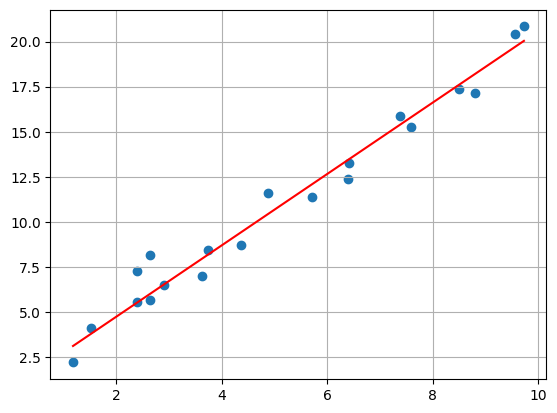

In [806]:
plt.scatter(X, y)
x = np.linspace(np.min(X), np.max(X), 100)
y3 = x * theta[0] + theta_0
plt.grid(True)
plt.plot(x, y3, color = 'red')
plt.show()

In [807]:
X_new = np.random.uniform(-10, 0, (100, 1))
y_new = (2 * X_new + 1 + np.random.normal(0, 1, (100, 1))).reshape(-1)
print(f'My Linear Regression: {linreg.score(X_new, y_new):.8f}')
y_pred = linreg_.predict(X_new)
print(f'Sklearn Regresion: {r2_score(y_new, y_pred):.8f}')

My Linear Regression: 0.97666284
Sklearn Regresion: 0.97000852


Используя датасет про автомобили (целевой признак — price), сравнить (качество, скорость обучения и предсказания, важность признаков) модели `MyLinearRegression` с различными гиперпараметрами, сделать выводы. На этом же датасете сравнить модель `MyLinearRegression` с библиотечной реализацией из `sklearn`, составить таблицу(ы) (графики) результатов сравнения (качество, скорость обучения и предсказания, важность признаков).

In [808]:
df = pd.read_csv('./data/data.csv')
df.head()

,model,engine_power,transmission,age_in_days,km,previous_owners,lat,lon,price
0,pop,69,manual,4474,56779,2,45.071079,7.46403,4490
1,lounge,69,manual,2708,160000,1,45.069679,7.70492,4500
2,lounge,69,automatic,3470,170000,2,45.514599,9.28434,4500
3,sport,69,manual,3288,132000,2,41.903221,12.49565,4700
4,sport,69,manual,3712,124490,2,45.532661,9.03892,4790


In [809]:
df.dtypes

model               object
engine_power         int64
transmission        object
age_in_days          int64
km                   int64
previous_owners      int64
lat                float64
lon                float64
price                int64
dtype: object

Избавимся от категориальных данных

In [823]:
X = df.drop(columns = ['model', 'transmission', 'previous_owners', 'price']).to_numpy()
y = df['price'].to_numpy()
X = (X - X.mean(axis = 0)) / X.std(axis = 0)

Разделим данные на тренировочные и тестовые

In [824]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

linreg_ = LinearRegression()
linreg_.fit(X_train, y_train)

y_pred = linreg_.predict(X_test)
print(f'Sklearn Regresion: {r2_score(y_test, y_pred):.8f}')

Sklearn Regresion: 0.89430295


In [825]:
# Без регуляризации
weight_calcs = ['matrix', 'gd', 'sgd']

for weight_calc in weight_calcs:

    linreg = MyLinearRegression(weight_calc = weight_calc)
    linreg.fit(X_train, y_train)
    
    print(f'Weight_calc = {weight_calc}')
    score = linreg.score(X_test, y_test)
    print(f'My Linear Regression: {score:.8f}')

Weight_calc = matrix
My Linear Regression: 0.89430295
Weight_calc = gd
My Linear Regression: 0.89221028
Weight_calc = sgd
My Linear Regression: 0.89397282


In [ ]:
# С регуляризацией
weight_calcs = ['gd', 'sgd']

alphas = {'l1': [0.0001, 0.001, 0.01, 0.1, 1],
          'l2': [0.001, 0.01, 0.1, 1, 10, 100],
          'l1l2': [0.1, 0.3, 0.5, 0.7, 0.9,
                   0.001, 0.01, 0.1, 1, 10]
        }

data = []
for weight_calc in weight_calcs:
    for item in alphas.items():
        for i in range(len(item[1]) if item[0] != 'l1l2' else len(item[1]) // 2):
            lambda_1, lambda_2 = 0, 0
            if item[0] == 'l1':
                lambda_1 = item[1][i]
                linreg = MyLinearRegression(weight_calc = weight_calc, regularization = item[0], lambda_1 = lambda_1)

                sklearn_model = Lasso(alpha = lambda_1, max_iter = 5000, random_state = 42)
                sklearn_model.fit(X_train, y_train)
                sklearn_score = sklearn_model.score(X_test, y_test)
                data.append(['', 'sklearn_l1', lambda_1, 0, sklearn_score])
            elif item[0] == 'l2':
                lambda_2 = item[1][i]
                linreg = MyLinearRegression(weight_calc = weight_calc, regularization = item[0], lambda_2 = lambda_2)

                sklearn_model = Ridge(alpha = lambda_2, max_iter = 5000, random_state = 42)
                sklearn_model.fit(X_train, y_train)
                sklearn_score = sklearn_model.score(X_test, y_test)
                data.append(['', 'sklearn_l2', 0, lambda_2, sklearn_score])
            else:
                lambda_1 = item[1][i]
                lambda_2 = item[1][i + 5]
                linreg = MyLinearRegression(weight_calc = weight_calc, regularization = item[0], 
                                            lambda_1 = item[1][i], lambda_2 = item[1][i + 5])
                
                sklearn_model = ElasticNet(alpha = lambda_1 + lambda_2,
                                           l1_ratio = lambda_1 / (lambda_1 + lambda_2 + 1e-8),
                                            max_iter = 5000, random_state = 42)
                sklearn_model.fit(X_train, y_train)
                sklearn_score = sklearn_model.score(X_test, y_test)
                data.append(['', 'sklearn_elasticnet', lambda_1, lambda_2, sklearn_score])
            
            linreg.fit(X_train, y_train)
            score = linreg.score(X_test, y_test)
            data.append([weight_calc, item[0], lambda_1, lambda_2, score])

df_regularization = pd.DataFrame(data, columns = ['weight_calc', 'reg', 'lambda_1', 'lambda_2', 'score'])
df_regularization

,weight_calc,reg,lambda_1,lambda_2,score
0,,sklearn_l1,0.0001,0.0,0.894303
1,gd,l1,0.0001,0.0,0.892210
2,,sklearn_l1,0.0010,0.0,0.894303
3,gd,l1,0.0010,0.0,0.892210
4,,sklearn_l1,0.0100,0.0,0.894303
...,...,...,...,...,...
59,sgd,l1l2,0.5000,0.1,0.893739
60,,sklearn_elasticnet,0.7000,1.0,0.743686
61,sgd,l1l2,0.7000,1.0,0.890070
62,,sklearn_elasticnet,0.9000,10.0,0.208085


In [818]:
df_regularization[df_regularization['score'] == df_regularization['score'].max()].head(1)

,weight_calc,reg,lambda_1,lambda_2,score
0,,sklearn_l1,0.0001,0.0,0.894303


## Задача 2

[Соревнование на Kaggle](https://kaggle.com/competitions/yadro-regression-2025)